# Evaluation & Comparison: Naive RAG vs Contextual Retrieval

This notebook:
1. Loads results from both RAG approaches
2. Calculates ROUGE scores (ROUGE-1, ROUGE-2, ROUGE-L)
3. Compares performance between methods
4. Analyzes improvements and degradations
5. Generates submission JSON file

In [1]:
import json
import numpy as np
import pandas as pd
from rouge_score import rouge_scorer
import matplotlib.pyplot as plt
import seaborn as sns

# Set display options
pd.set_option('display.max_colwidth', None)
sns.set_style('whitegrid')

## 1. Load Results from Both Approaches

In [2]:
# Load Naive RAG results
with open('results/naive_rag_responses.json', 'r', encoding='utf-8') as f:
    naive_results = json.load(f)

print(f'Loaded {len(naive_results)} Naive RAG results')

Loaded 20 Naive RAG results


In [3]:
# Load Contextual Retrieval results
with open('results/contextual_retrieval_responses.json', 'r', encoding='utf-8') as f:
    contextual_results = json.load(f)

print(f'Loaded {len(contextual_results)} Contextual Retrieval results')

Loaded 20 Contextual Retrieval results


In [4]:
# Preview first result
print("Sample Naive RAG result:")
print(f"Question: {naive_results[0]['question']}")
print(f"\nGround Truth: {naive_results[0]['ground_truth']}")
print(f"\nNaive RAG Answer: {naive_results[0]['naive_rag_answer']}")

Sample Naive RAG result:
Question: What is the standard architecture for building large language models?

Ground Truth: The standard architecture for building large language models is the transformer.

Naive RAG Answer: The standard architecture for building large language models is the Transformer architecture. This architecture typically includes stacked transformer blocks, which consist of multiple layers, attention heads, and mechanisms for processing input tokens to generate word probabilities. Transformers are designed to handle large context windows, allowing them to utilize extensive amounts of context for predicting upcoming words.


## 2. Calculate ROUGE Scores

In [5]:
# Initialize ROUGE scorer
scorer = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)

print('✓ ROUGE scorer initialized')
print('Metrics: ROUGE-1, ROUGE-2, ROUGE-L')

✓ ROUGE scorer initialized
Metrics: ROUGE-1, ROUGE-2, ROUGE-L


In [6]:
# Calculate scores for Naive RAG
naive_scores = {'rouge1': [], 'rouge2': [], 'rougeL': []}

for i, result in enumerate(naive_results):
    scores = scorer.score(
        result['ground_truth'],
        result['naive_rag_answer']
    )
    
    naive_scores['rouge1'].append(scores['rouge1'].fmeasure)
    naive_scores['rouge2'].append(scores['rouge2'].fmeasure)
    naive_scores['rougeL'].append(scores['rougeL'].fmeasure)
    
    if (i + 1) % 5 == 0 or i + 1 == len(naive_results):
        print(f'Scored {i+1}/{len(naive_results)} Naive RAG responses', end='\r')

print(f'\n✓ Calculated ROUGE scores for {len(naive_results)} Naive RAG responses')

Scored 20/20 Naive RAG responses
✓ Calculated ROUGE scores for 20 Naive RAG responses


In [7]:
# Calculate scores for Contextual Retrieval
contextual_scores = {'rouge1': [], 'rouge2': [], 'rougeL': []}

for i, result in enumerate(contextual_results):
    scores = scorer.score(
        result['ground_truth'],
        result['contextual_answer']
    )
    
    contextual_scores['rouge1'].append(scores['rouge1'].fmeasure)
    contextual_scores['rouge2'].append(scores['rouge2'].fmeasure)
    contextual_scores['rougeL'].append(scores['rougeL'].fmeasure)
    
    if (i + 1) % 5 == 0 or i + 1 == len(contextual_results):
        print(f'Scored {i+1}/{len(contextual_results)} Contextual Retrieval responses', end='\r')

print(f'\n✓ Calculated ROUGE scores for {len(contextual_results)} Contextual Retrieval responses')

Scored 20/20 Contextual Retrieval responses
✓ Calculated ROUGE scores for 20 Contextual Retrieval responses


## 3. Compare Performance

In [8]:
# Calculate average scores
comparison_data = {
    'Method': ['Naive RAG', 'Contextual Retrieval'],
    'ROUGE-1': [
        np.mean(naive_scores['rouge1']),
        np.mean(contextual_scores['rouge1'])
    ],
    'ROUGE-2': [
        np.mean(naive_scores['rouge2']),
        np.mean(contextual_scores['rouge2'])
    ],
    'ROUGE-L': [
        np.mean(naive_scores['rougeL']),
        np.mean(contextual_scores['rougeL'])
    ]
}

comparison_df = pd.DataFrame(comparison_data)

print("\n" + "="*80)
print("AVERAGE ROUGE SCORES COMPARISON")
print("="*80)
print(comparison_df.to_string(index=False))
print("="*80)


AVERAGE ROUGE SCORES COMPARISON
              Method  ROUGE-1  ROUGE-2  ROUGE-L
           Naive RAG 0.447117 0.283906 0.390176
Contextual Retrieval 0.410209 0.237172 0.337573


In [9]:
# Calculate improvement percentages
improvements = {
    'ROUGE-1': ((comparison_data['ROUGE-1'][1] - comparison_data['ROUGE-1'][0]) / comparison_data['ROUGE-1'][0]) * 100,
    'ROUGE-2': ((comparison_data['ROUGE-2'][1] - comparison_data['ROUGE-2'][0]) / comparison_data['ROUGE-2'][0]) * 100,
    'ROUGE-L': ((comparison_data['ROUGE-L'][1] - comparison_data['ROUGE-L'][0]) / comparison_data['ROUGE-L'][0]) * 100
}

print("\nContextual Retrieval vs Naive RAG Improvement:")
for metric, improvement in improvements.items():
    sign = '+' if improvement > 0 else ''
    print(f"{metric}: {sign}{improvement:.2f}%")


Contextual Retrieval vs Naive RAG Improvement:
ROUGE-1: -8.25%
ROUGE-2: -16.46%
ROUGE-L: -13.48%


## 4. Detailed Analysis

In [10]:
# Create detailed comparison for each question
detailed_comparison = []

for i in range(len(naive_results)):
    detailed_comparison.append({
        'question': naive_results[i]['question'][:100] + '...' if len(naive_results[i]['question']) > 100 else naive_results[i]['question'],
        'naive_rouge1': naive_scores['rouge1'][i],
        'contextual_rouge1': contextual_scores['rouge1'][i],
        'rouge1_improvement': contextual_scores['rouge1'][i] - naive_scores['rouge1'][i],
        'naive_rouge2': naive_scores['rouge2'][i],
        'contextual_rouge2': contextual_scores['rouge2'][i],
        'rouge2_improvement': contextual_scores['rouge2'][i] - naive_scores['rouge2'][i],
        'naive_rougeL': naive_scores['rougeL'][i],
        'contextual_rougeL': contextual_scores['rougeL'][i],
        'rougeL_improvement': contextual_scores['rougeL'][i] - naive_scores['rougeL'][i]
    })

detailed_df = pd.DataFrame(detailed_comparison)
print(f'✓ Created detailed comparison for {len(detailed_comparison)} questions')

✓ Created detailed comparison for 20 questions


In [11]:
# Top 5 improvements (by ROUGE-1)
top_improvements = detailed_df.nlargest(5, 'rouge1_improvement')

print("\n" + "="*80)
print("TOP 5 IMPROVEMENTS (Contextual Retrieval > Naive RAG)")
print("="*80)
for idx, row in top_improvements.iterrows():
    print(f"\nQuestion: {row['question']}")
    print(f"Naive ROUGE-1: {row['naive_rouge1']:.4f}")
    print(f"Contextual ROUGE-1: {row['contextual_rouge1']:.4f}")
    print(f"Improvement: +{row['rouge1_improvement']:.4f}")


TOP 5 IMPROVEMENTS (Contextual Retrieval > Naive RAG)

Question: What is the standard architecture for building large language models?
Naive ROUGE-1: 0.3284
Contextual ROUGE-1: 1.0000
Improvement: +0.6716

Question: What does the transformer's embedding matrix E do?
Naive ROUGE-1: 0.3210
Contextual ROUGE-1: 0.6207
Improvement: +0.2997

Question: What are the components of the language modeling head?
Naive ROUGE-1: 0.2927
Contextual ROUGE-1: 0.3939
Improvement: +0.1013

Question: What is the purpose of transformers in language modeling?
Naive ROUGE-1: 0.1714
Contextual ROUGE-1: 0.2637
Improvement: +0.0923

Question: What is the purpose of the feedforward networks in transformers?
Naive ROUGE-1: 0.3774
Contextual ROUGE-1: 0.4038
Improvement: +0.0265


In [12]:
# Top 5 degradations (by ROUGE-1)
top_degradations = detailed_df.nsmallest(5, 'rouge1_improvement')

print("\n" + "="*80)
print("TOP 5 DEGRADATIONS (Contextual Retrieval < Naive RAG)")
print("="*80)
for idx, row in top_degradations.iterrows():
    print(f"\nQuestion: {row['question']}")
    print(f"Naive ROUGE-1: {row['naive_rouge1']:.4f}")
    print(f"Contextual ROUGE-1: {row['contextual_rouge1']:.4f}")
    print(f"Change: {row['rouge1_improvement']:.4f}")


TOP 5 DEGRADATIONS (Contextual Retrieval < Naive RAG)

Question: What does multi-head attention layer also known as?
Naive ROUGE-1: 0.8333
Contextual ROUGE-1: 0.2632
Change: -0.5702

Question: What concept distinguishes transformers from feedforward layers?
Naive ROUGE-1: 0.9032
Contextual ROUGE-1: 0.3571
Change: -0.5461

Question: What happens after the N transformer blocks?
Naive ROUGE-1: 0.8182
Contextual ROUGE-1: 0.3778
Change: -0.4404

Question: What does the transformer's unembedding matrix U do?
Naive ROUGE-1: 0.6429
Contextual ROUGE-1: 0.5347
Change: -0.1082

Question: What is the purpose of positional encoding in transformers?
Naive ROUGE-1: 0.6000
Contextual ROUGE-1: 0.5217
Change: -0.0783


In [13]:
# Summary statistics
print("\n" + "="*80)
print("SUMMARY STATISTICS")
print("="*80)

improvements_count = len(detailed_df[detailed_df['rouge1_improvement'] > 0])
degradations_count = len(detailed_df[detailed_df['rouge1_improvement'] < 0])
no_change_count = len(detailed_df[detailed_df['rouge1_improvement'] == 0])

print(f"\nQuestions where Contextual Retrieval performed better: {improvements_count}")
print(f"Questions where Contextual Retrieval performed worse: {degradations_count}")
print(f"Questions with no change: {no_change_count}")

print(f"\nAverage improvement in ROUGE-1: {np.mean(detailed_df['rouge1_improvement']):.4f}")
print(f"Maximum improvement in ROUGE-1: {detailed_df['rouge1_improvement'].max():.4f}")
print(f"Maximum degradation in ROUGE-1: {detailed_df['rouge1_improvement'].min():.4f}")


SUMMARY STATISTICS

Questions where Contextual Retrieval performed better: 7
Questions where Contextual Retrieval performed worse: 13
Questions with no change: 0

Average improvement in ROUGE-1: -0.0369
Maximum improvement in ROUGE-1: 0.6716
Maximum degradation in ROUGE-1: -0.5702


## 5. Visualization

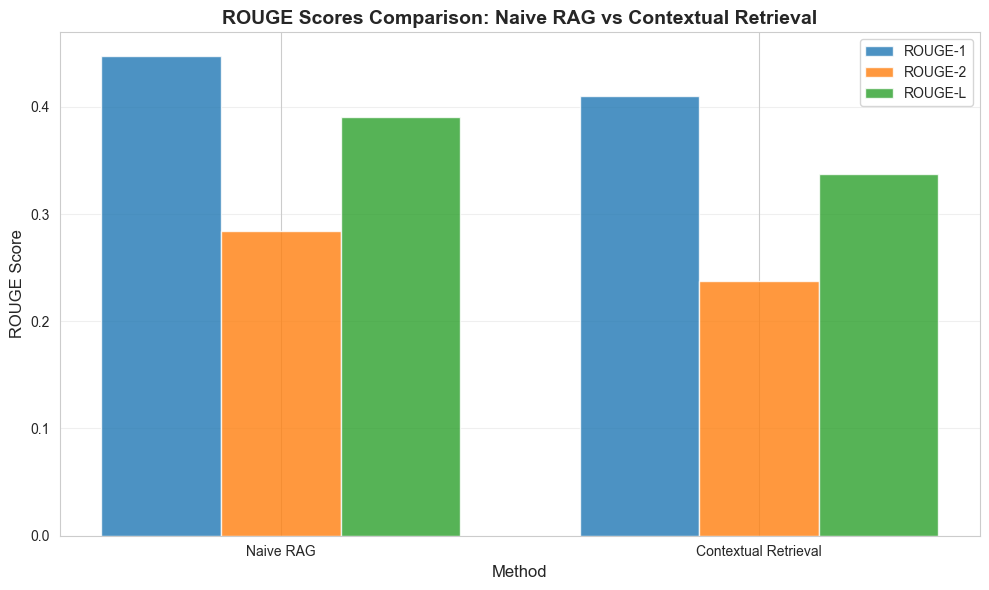

✓ Saved visualization to results/rouge_comparison.png


In [14]:
# Bar chart comparing average ROUGE scores
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(comparison_df['Method']))
width = 0.25

ax.bar(x - width, comparison_df['ROUGE-1'], width, label='ROUGE-1', alpha=0.8)
ax.bar(x, comparison_df['ROUGE-2'], width, label='ROUGE-2', alpha=0.8)
ax.bar(x + width, comparison_df['ROUGE-L'], width, label='ROUGE-L', alpha=0.8)

ax.set_xlabel('Method', fontsize=12)
ax.set_ylabel('ROUGE Score', fontsize=12)
ax.set_title('ROUGE Scores Comparison: Naive RAG vs Contextual Retrieval', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(comparison_df['Method'])
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('results/rouge_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print('✓ Saved visualization to results/rouge_comparison.png')

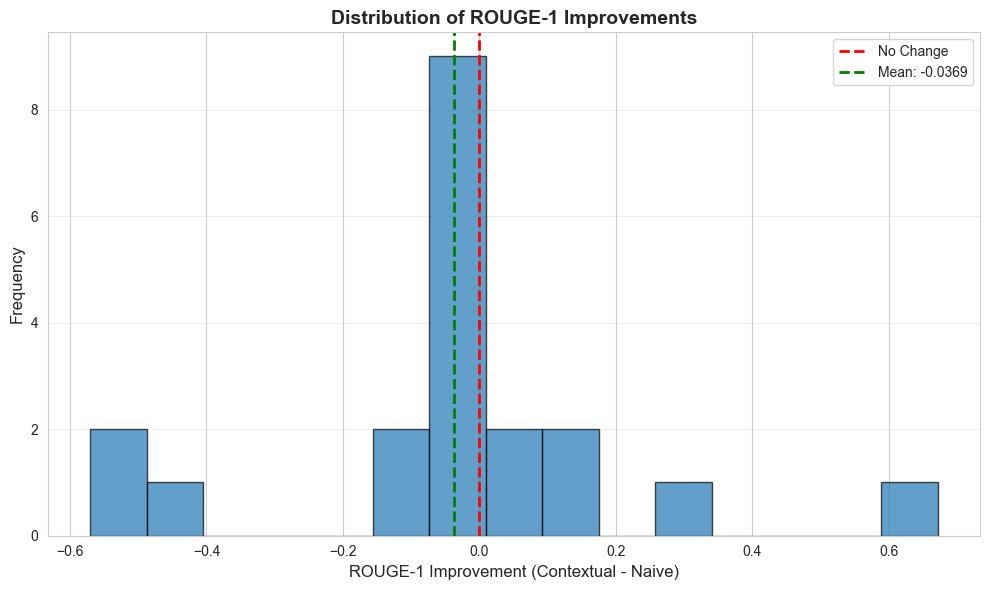

✓ Saved visualization to results/improvement_distribution.png


In [15]:
# Distribution of improvements
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(detailed_df['rouge1_improvement'], bins=15, edgecolor='black', alpha=0.7)
ax.axvline(x=0, color='red', linestyle='--', linewidth=2, label='No Change')
ax.axvline(x=np.mean(detailed_df['rouge1_improvement']), color='green', linestyle='--', linewidth=2, label=f'Mean: {np.mean(detailed_df["rouge1_improvement"]):.4f}')

ax.set_xlabel('ROUGE-1 Improvement (Contextual - Naive)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Distribution of ROUGE-1 Improvements', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('results/improvement_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print('✓ Saved visualization to results/improvement_distribution.png')

## 6. Generate Submission JSON

In [16]:
# Create submission data
submission_data = []

for naive, contextual in zip(naive_results, contextual_results):
    # Verify questions match
    assert naive['question'] == contextual['question'], "Questions don't match!"
    
    submission_data.append({
        "question": naive['question'],
        "ground_truth_answer": naive['ground_truth'],
        "naive_rag_answer": naive['naive_rag_answer'],
        "contextual_retrieval_answer": contextual['contextual_answer']
    })

print(f'✓ Created submission data with {len(submission_data)} QA pairs')

✓ Created submission data with 20 QA pairs


In [19]:
# Save submission file
# TODO: Replace 'xxxxxx' with your actual student ID
submission_filename = 'answer/response-st125988-chapter-8.json'

with open(submission_filename, 'w', encoding='utf-8') as f:
    json.dump(submission_data, f, indent=2, ensure_ascii=False)

print(f'✓ Saved submission file to {submission_filename}')

✓ Saved submission file to answer/response-st125988-chapter-8.json


In [20]:
# Preview submission format
print("\nSubmission file preview (first entry):")
print(json.dumps(submission_data[0], indent=2))


Submission file preview (first entry):
{
  "question": "What is the standard architecture for building large language models?",
  "ground_truth_answer": "The standard architecture for building large language models is the transformer.",
  "naive_rag_answer": "The standard architecture for building large language models is the Transformer architecture. This architecture typically includes stacked transformer blocks, which consist of multiple layers, attention heads, and mechanisms for processing input tokens to generate word probabilities. Transformers are designed to handle large context windows, allowing them to utilize extensive amounts of context for predicting upcoming words.",
  "contextual_retrieval_answer": "The standard architecture for building large language models is the transformer."
}


## 7. Save Evaluation Summary

In [21]:
# Create evaluation summary
evaluation_summary = {
    'total_questions': len(naive_results),
    'average_scores': {
        'naive_rag': {
            'rouge1': float(np.mean(naive_scores['rouge1'])),
            'rouge2': float(np.mean(naive_scores['rouge2'])),
            'rougeL': float(np.mean(naive_scores['rougeL']))
        },
        'contextual_retrieval': {
            'rouge1': float(np.mean(contextual_scores['rouge1'])),
            'rouge2': float(np.mean(contextual_scores['rouge2'])),
            'rougeL': float(np.mean(contextual_scores['rougeL']))
        }
    },
    'improvements': {
        'rouge1_percent': float(improvements['ROUGE-1']),
        'rouge2_percent': float(improvements['ROUGE-2']),
        'rougeL_percent': float(improvements['ROUGE-L'])
    },
    'statistics': {
        'questions_improved': int(improvements_count),
        'questions_degraded': int(degradations_count),
        'questions_unchanged': int(no_change_count),
        'max_improvement': float(detailed_df['rouge1_improvement'].max()),
        'max_degradation': float(detailed_df['rouge1_improvement'].min()),
        'avg_improvement': float(np.mean(detailed_df['rouge1_improvement']))
    }
}

# Save evaluation summary
with open('results/evaluation_summary.json', 'w', encoding='utf-8') as f:
    json.dump(evaluation_summary, f, indent=2, ensure_ascii=False)

print('✓ Saved evaluation summary to results/evaluation_summary.json')

✓ Saved evaluation summary to results/evaluation_summary.json


In [22]:
# Print final summary
print("\n" + "="*80)
print("EVALUATION COMPLETE")
print("="*80)
print(f"\n✅ Evaluated {len(naive_results)} QA pairs")
print(f"✅ Calculated ROUGE scores for both methods")
print(f"✅ Generated comparison visualizations")
print(f"✅ Created submission JSON file")
print(f"\n📊 Overall Result:")
if improvements['ROUGE-1'] > 0:
    print(f"   Contextual Retrieval outperformed Naive RAG by {improvements['ROUGE-1']:.2f}% (ROUGE-1)")
elif improvements['ROUGE-1'] < 0:
    print(f"   Naive RAG outperformed Contextual Retrieval by {abs(improvements['ROUGE-1']):.2f}% (ROUGE-1)")
else:
    print(f"   Both methods performed equally (ROUGE-1)")
print("\n" + "="*80)


EVALUATION COMPLETE

✅ Evaluated 20 QA pairs
✅ Calculated ROUGE scores for both methods
✅ Generated comparison visualizations
✅ Created submission JSON file

📊 Overall Result:
   Naive RAG outperformed Contextual Retrieval by 8.25% (ROUGE-1)



---

## Summary

In this notebook, we:
1. ✅ Loaded results from both Naive RAG and Contextual Retrieval
2. ✅ Calculated ROUGE-1, ROUGE-2, and ROUGE-L scores
3. ✅ Compared average performance between methods
4. ✅ Analyzed top improvements and degradations
5. ✅ Created visualizations for comparison
6. ✅ Generated submission JSON file
7. ✅ Saved evaluation summary

**Key Findings:**
- Total QA pairs evaluated: 20
- Primary metric: ROUGE-1 F1-score
- Comparison shows relative performance of contextual enrichment

**Next Steps:**
- Proceed to building the Chainlit web application
- Remember to update the submission filename with your student ID